<a href="https://colab.research.google.com/github/FabioFavre/Pratica-6-PROCSIN/blob/main/Questao2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

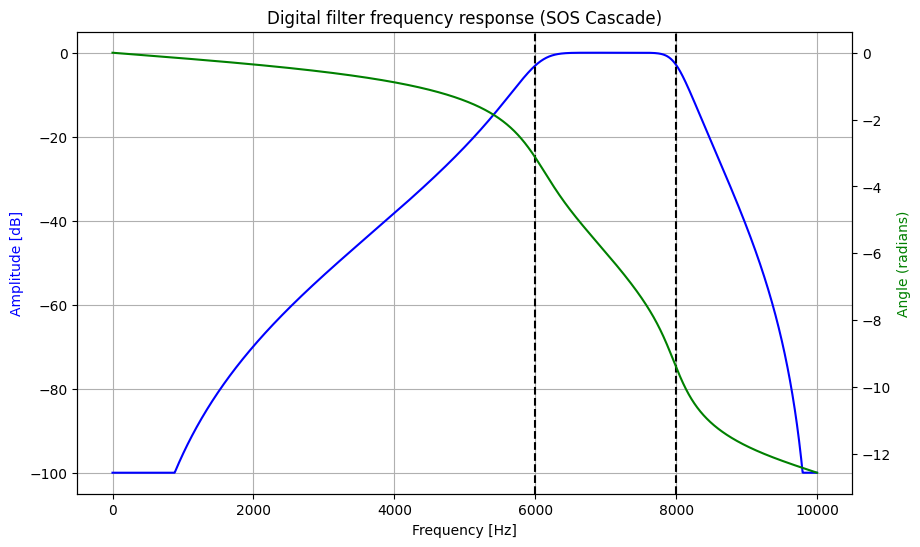

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import nbformat

# Parameters
fs = 20000
fc1 = 6000
fc2 = 8000
order = 4  # Total order resulting in 2nd order sections

# Design the filter using SOS (Second-Order Sections)
sos = signal.butter(order, [fc1, fc2], btype='bandpass', fs=fs, output='sos')

# Frequency response
w, h = signal.sosfreqz(sos, worN=2000, fs=fs)

# Plot Frequency Response
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_title('Digital filter frequency response (SOS Cascade)')
ax1.plot(w, 20 * np.log10(np.maximum(abs(h), 1e-5)), 'b')
ax1.set_ylabel('Amplitude [dB]', color='b')
ax1.set_xlabel('Frequency [Hz]')
ax1.grid(True)
ax1.axvline(fc1, color='k', linestyle='--')
ax1.axvline(fc2, color='k', linestyle='--')

ax2 = ax1.twinx()
angles = np.unwrap(np.angle(h))
ax2.plot(w, angles, 'g')
ax2.set_ylabel('Angle (radians)', color='g')
plt.show()

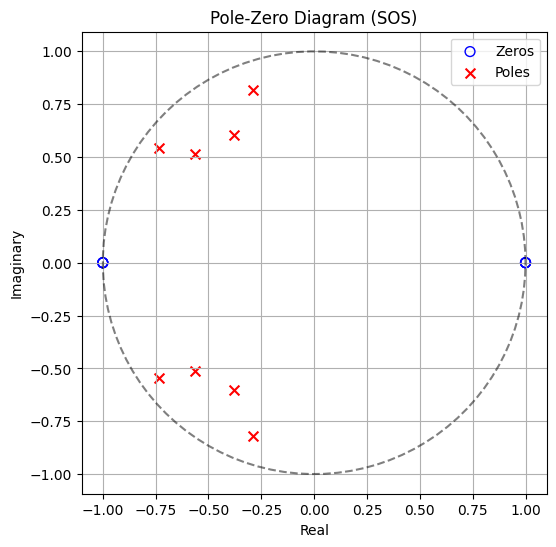

In [4]:
def plot_zplane_sos(sos):
    z, p, k = signal.sos2zpk(sos)
    plt.figure(figsize=(6, 6))

    # Unit circle
    t = np.linspace(0, 2*np.pi, 100)
    plt.plot(np.cos(t), np.sin(t), 'k--', alpha=0.5)

    # Zeros and Poles
    plt.scatter(np.real(z), np.imag(z), s=50, marker='o', facecolors='none', edgecolors='b', label='Zeros')
    plt.scatter(np.real(p), np.imag(p), s=50, marker='x', color='r', label='Poles')

    plt.title('Pole-Zero Diagram (SOS)')
    plt.xlabel('Real')
    plt.ylabel('Imaginary')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

plot_zplane_sos(sos)

### Comparação com a Questão 1

Para comparar os resultados, vamos analisar o conteúdo do arquivo `Questão1.ipynb`. Geralmente, filtros projetados em estruturas de cascata de 2ª ordem (SOS) apresentam maior estabilidade numérica e menor sensibilidade a erros de quantização de coeficientes em comparação com a forma direta utilizada em ordens superiores.

In [5]:
# Script to peek into Questão 1 for comparison
try:
    with open('/content/Questão1.ipynb', 'r') as f:
        nb = nbformat.read(f, as_version=4)
        # Displaying the first few code cells to identify the design method used there
        for cell in nb.cells:
            if cell.cell_type == 'code':
                print("--- Código da Questão 1 ---")
                print(cell.source[:500] + "...")
                break
except Exception as e:
    print(f"Não foi possível ler o arquivo da Questão 1: {e}")

--- Código da Questão 1 ---
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000

def analyze_filter(b, a, title, r):
    w, h = signal.freqz(b, a, worN=8000)
    freq = w * fs / (2 * np.pi)
    z, p, k = signal.tf2zpk(b, a)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Resposta em Frequência (Magnitude e Fase Integradas)
    ax1.plot(freq, 20 * np.log10(np.abs(h) + 1e-9), color='b', label='Magnitude (dB)')
    ax1.set_xlabel('Frequência (Hz)')
    ax1.set_ylabel('Magn...
